## Section 1: SQL in R

SQL queries executed within R using the sqldf library to investigate
NorthStar's operational inefficiencies across deliveries, hubs, drivers,
complaints and zones. Each query targets a specific business problem
identified in the case study.

In [ ]:
list.files()

[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "README.txt"          "sample_data"         "vehicles.csv"

In [ ]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(sqldf)
library(ggplot2)
library(dplyr)
library(tidyr)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE)
orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE)
drivers    <- read.csv("drivers.csv",    stringsAsFactors = FALSE)
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors = FALSE)
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE)
incidents  <- read.csv("incidents.csv",  stringsAsFactors = FALSE)
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE)
app_events <- read.csv("app_events.csv", stringsAsFactors = FALSE)

cat("All files loaded!\n")
cat("customers:", nrow(customers), "rows\n")
cat("orders:", nrow(orders), "rows\n")
cat("deliveries:", nrow(deliveries), "rows\n")
cat("drivers:", nrow(drivers), "rows\n")
cat("vehicles:", nrow(vehicles), "rows\n")
cat("hubs:", nrow(hubs), "rows\n")
cat("incidents:", nrow(incidents), "rows\n")
cat("complaints:", nrow(complaints), "rows\n")
cat("app_events:", nrow(app_events), "rows\n")

All files loaded!
customers: 650 rows
orders: 1250 rows
deliveries: 950 rows
drivers: 170 rows
vehicles: 120 rows
hubs: 8 rows
incidents: 280 rows
complaints: 320 rows
app_events: 640 rows


In [ ]:
# Zone names are inconsistent across files e.g. "NORTH", "north", "North", "Ctr" for Central
# This must be fixed before any GROUP BY or JOIN on zone columns

standardise_zone <- function(x) {
  x <- trimws(tolower(x))
  x <- gsub("^ctr$", "central", x)
  x <- tools::toTitleCase(x)
  return(x)
}

customers$home_zone      <- standardise_zone(customers$home_zone)
orders$pickup_zone       <- standardise_zone(orders$pickup_zone)
orders$dropoff_zone      <- standardise_zone(orders$dropoff_zone)
drivers$base_zone        <- standardise_zone(drivers$base_zone)
vehicles$assigned_zone   <- standardise_zone(vehicles$assigned_zone)
hubs$zone                <- standardise_zone(hubs$zone)
app_events$zone_context  <- standardise_zone(app_events$zone_context)

cat("Zone standardisation complete!\n")
cat("Unique zones in orders:", paste(unique(orders$pickup_zone), collapse=", "), "\n")

Zone standardisation complete!
Unique zones in orders: Airport, North, West, Riverside, Central, South, East 


In [ ]:
# SQL Query 1: Overall delivery outcome breakdown
# Business question: What is the baseline failure and delay rate across all deliveries?

q1 <- sqldf("
  SELECT
    delivery_status,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(fuel_or_charge_cost), 2) AS avg_cost,
    ROUND(AVG(manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

print(q1)

  delivery_status total_deliveries avg_cost avg_overrides avg_rating
1          OnTime              616    12.68          0.92       4.28
2         Delayed              202    13.14          1.07       3.11
3          Failed              132    13.15          1.04       3.05


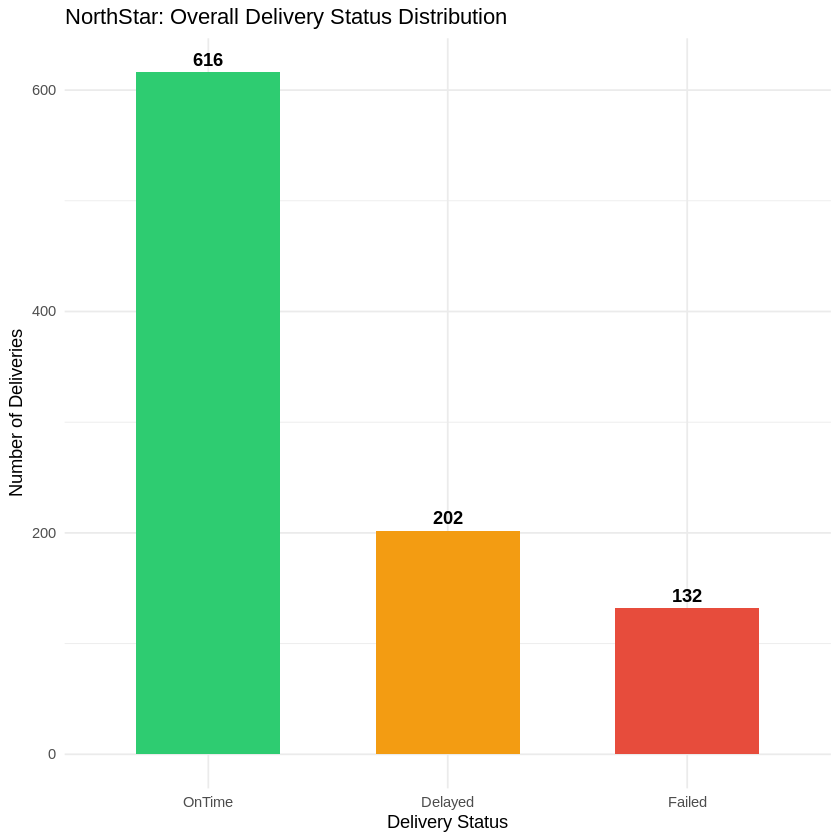

In [ ]:
ggplot(q1, aes(x = reorder(delivery_status, -total_deliveries),
               y = total_deliveries,
               fill = delivery_status)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = total_deliveries), vjust = -0.5, fontface = "bold") +
  scale_fill_manual(values = c("OnTime"="#2ecc71", "Delayed"="#f39c12", "Failed"="#e74c3c")) +
  labs(title = "NorthStar: Overall Delivery Status Distribution",
       x = "Delivery Status", y = "Number of Deliveries") +
  theme_minimal() +
  theme(legend.position = "none")

In [ ]:
# SQL Query 2: Which hubs have the highest failure rates?
# Business question: The operations director suspects certain hubs underperform

q2 <- sqldf("
  SELECT
    d.hub_id,
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 1
    ) AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone
  ORDER BY failure_rate_pct DESC
")

print(q2)

  hub_id       hub_name      zone total_deliveries failed delayed
1    H05   Central Core   Central              115     23      25
2    H06    Airport Hub   Airport              104     15      27
3    H08  Midtown Relay   Central              128     26      22
4    H04      West Gate      West              127     16      28
5    H02     South Link     South              106     10      26
6    H07  Riverside Hub Riverside              115     14      25
7    H01 North Exchange     North              136     17      26
8    H03      East Dock      East              119     11      23
  failure_rate_pct avg_cost
1             41.7    13.69
2             40.4    13.32
3             37.5    11.71
4             34.6    13.17
5             34.0    12.57
6             33.9    12.92
7             31.6    12.76
8             28.6    12.74


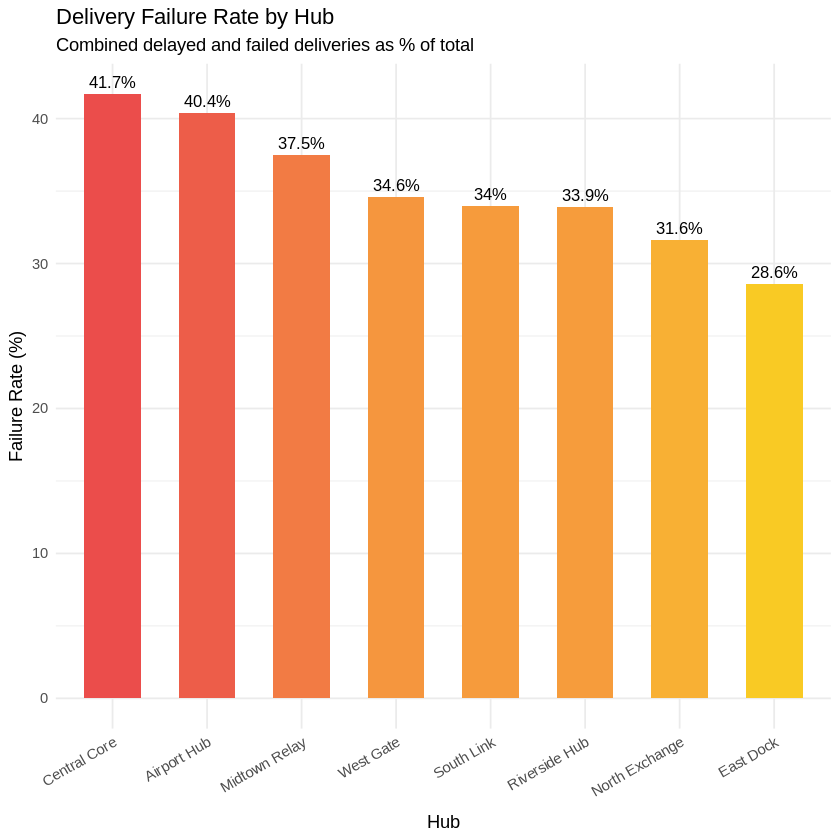

In [ ]:
ggplot(q2, aes(x = reorder(hub_name, -failure_rate_pct),
               y = failure_rate_pct,
               fill = failure_rate_pct)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(failure_rate_pct, "%")), vjust = -0.5, size = 3.5) +
  scale_fill_gradient(low = "#f9ca24", high = "#eb4d4b") +
  labs(title = "Delivery Failure Rate by Hub",
       subtitle = "Combined delayed and failed deliveries as % of total",
       x = "Hub", y = "Failure Rate (%)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
        legend.position = "none")

In [ ]:
# SQL Query 3: Which drivers have the most route overrides and does it link to failures?
# Business question: Are manual overrides masking poor planning or performance avoidance?

q3 <- sqldf("
  SELECT
    d.driver_id,
    dr.base_zone,
    dr.driver_rating,
    dr.training_score,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(d.manual_route_override_count) AS total_overrides,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  WHERE dr.training_score IS NOT NULL
  GROUP BY d.driver_id, dr.base_zone, dr.driver_rating, dr.training_score
  HAVING total_deliveries >= 3
  ORDER BY avg_overrides DESC
  LIMIT 15
")

print(q3)

   driver_id base_zone driver_rating training_score total_deliveries
1       D127   Central          4.19           61.5                6
2       D062     South          4.48           62.4                3
3       D069     North          5.00           61.5                7
4       D085     North          4.11           84.5                4
5       D105 Riverside          3.71           82.0                7
6       D124     North          3.78           70.6                4
7       D130      West          3.64           71.2                8
8       D139     South          4.99           71.4                5
9       D028     North          4.07           83.0                7
10      D027   Airport          3.70           74.3                6
11      D143   Central          4.14           68.5                5
12      D003   Airport          5.00           96.5                4
13      D107 Riverside          4.82           57.0                4
14      D136   Airport          3.

In [ ]:
# SQL Query 4: Are complaints linked to actual delivery failures?
# Business question: Customer experience director argues complaints and failures
# are not being connected - this query creates that unified view

q4 <- sqldf("
  SELECT
    c.complaint_type,
    c.severity,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS linked_failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS linked_delayed
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  JOIN deliveries d ON o.order_id = d.order_id
  WHERE c.compensation_amount IS NOT NULL
  GROUP BY c.complaint_type, c.severity
  ORDER BY total_complaints DESC
")

print(q4)

      complaint_type severity total_complaints avg_resolution_days
1              Delay   Medium               41                 6.0
2       MissedPickup   Medium               31                 6.7
3    DriverBehaviour   Medium               23                 5.6
4           AppIssue   Medium               17                 7.5
5              Delay      Low               16                 5.9
6              Delay     High               11                14.0
7  SupportExperience   Medium               11                 6.5
8           AppIssue     High                9                14.0
9           AppIssue      Low                9                 6.3
10   DriverBehaviour     High                9                14.1
11           Billing   Medium                7                 5.1
12      MissedPickup     High                7                11.1
13      MissedPickup      Low                6                 5.8
14            Damage     High                5                

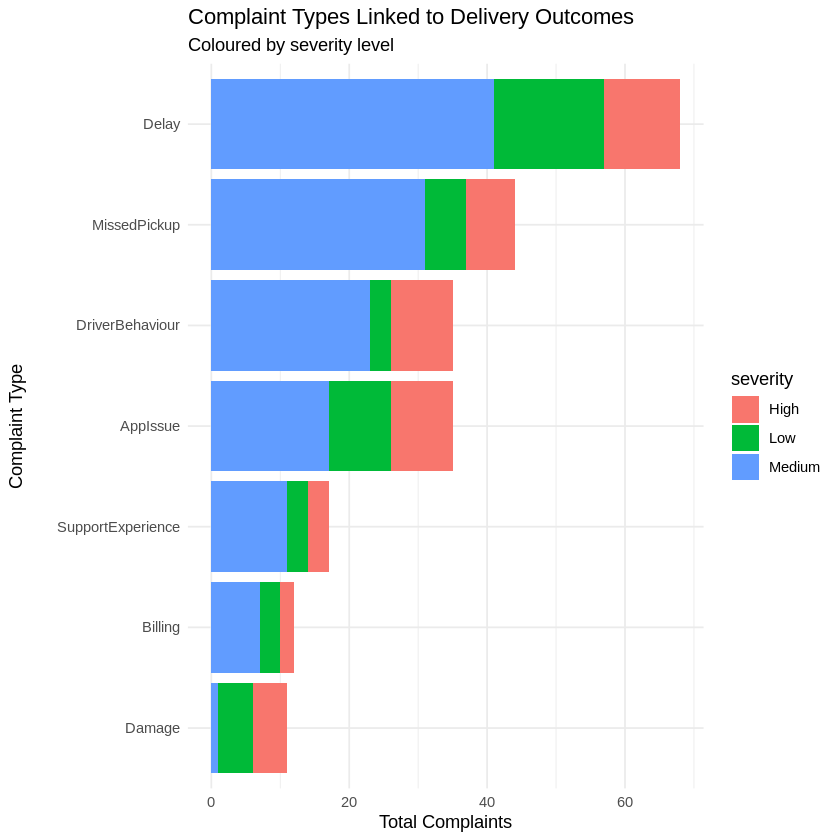

In [ ]:
ggplot(q4, aes(x = reorder(complaint_type, total_complaints),
               y = total_complaints,
               fill = severity)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Complaint Types Linked to Delivery Outcomes",
       subtitle = "Coloured by severity level",
       x = "Complaint Type", y = "Total Complaints") +
  theme_minimal()

In [ ]:
# SQL Query 5: Which zones consistently produce worse outcomes?
# Business question: Board noted some city zones perform worse but cannot explain why

q5 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END) AS ontime,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 1
    ) AS ontime_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY ontime_rate_pct ASC
")

print(q5)

  pickup_zone total_deliveries ontime delayed failed ontime_rate_pct avg_cost
1     Central              174     90      51     33            51.7    12.12
2     Airport              113     70      31     12            61.9    17.08
3   Riverside              119     76      25     18            63.9    12.39
4        East              156    106      31     19            67.9    12.57
5       North              135     92      21     22            68.1    12.07
6        West              114     79      21     14            69.3    11.94
7       South              139    103      22     14            74.1    12.48
  avg_overrides
1          1.29
2          1.81
3          0.73
4          0.79
5          0.70
6          0.81
7          0.69


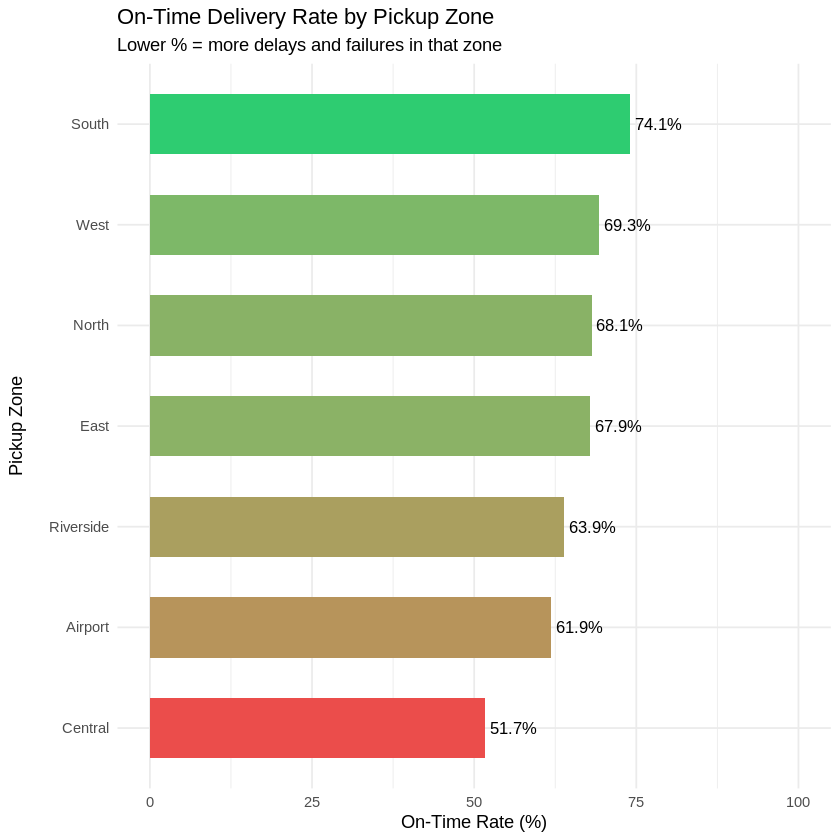

In [ ]:
ggplot(q5, aes(x = reorder(pickup_zone, ontime_rate_pct),
               y = ontime_rate_pct,
               fill = ontime_rate_pct)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(ontime_rate_pct, "%")), hjust = -0.1, size = 3.5) +
  coord_flip() +
  scale_fill_gradient(low = "#eb4d4b", high = "#2ecc71") +
  labs(title = "On-Time Delivery Rate by Pickup Zone",
       subtitle = "Lower % = more delays and failures in that zone",
       x = "Pickup Zone", y = "On-Time Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none") +
  ylim(0, 100)

In [ ]:
# SQL Query 6: Are vehicle maintenance issues linked to delivery failures?
# Business question: Management suspects maintenance faults are being detected too late

q6 <- sqldf("
  SELECT
    v.maintenance_status,
    v.vehicle_type,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 1
    ) AS failure_rate_pct,
    ROUND(AVG(v.battery_health_pct), 1) AS avg_battery_health,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  WHERE v.battery_health_pct IS NOT NULL
  GROUP BY v.maintenance_status, v.vehicle_type
  ORDER BY failure_rate_pct DESC
")

print(q6)

   maintenance_status vehicle_type total_deliveries failed delayed
1            InRepair     CargoVan               68     22      16
2            InRepair           EV               60     17      14
3            InRepair       Diesel               55     17      11
4            InRepair       Hybrid               71     21      11
5           Scheduled       Hybrid               42      2      16
6              Active     CargoVan              117     11      29
7           Scheduled     CargoVan               38      5       8
8              Active       Hybrid              112     13      22
9              Active           EV              208     11      47
10             Active       Diesel               80      8      11
11          Scheduled       Diesel                9      1       1
12          Scheduled           EV               65      2      12
   failure_rate_pct avg_battery_health avg_cost
1              55.9               69.8    12.46
2              51.7              

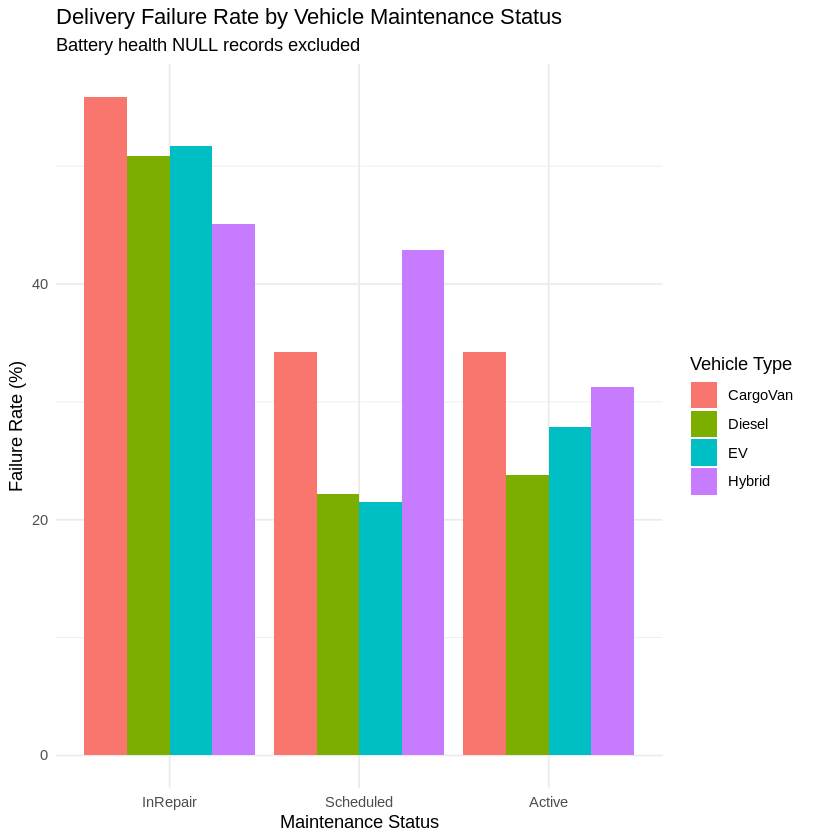

In [ ]:
ggplot(q6, aes(x = reorder(maintenance_status, -failure_rate_pct),
               y = failure_rate_pct,
               fill = vehicle_type)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Delivery Failure Rate by Vehicle Maintenance Status",
       subtitle = "Battery health NULL records excluded",
       x = "Maintenance Status", y = "Failure Rate (%)",
       fill = "Vehicle Type") +
  theme_minimal()

In [ ]:
# SQL Query 7: Which service types are most costly and failure prone?
# Business question: Finance director believes some service contracts are unprofitable

q7 <- sqldf("
  SELECT
    o.service_type,
    o.priority_level,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    ROUND(SUM(d.fuel_or_charge_cost), 2) AS total_cost,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type, o.priority_level
  ORDER BY total_cost DESC
")

print(q7)

   service_type priority_level total_deliveries avg_cost total_cost failed
1     Passenger         Medium              105    12.65    1328.58     13
2        Retail         Medium               97    13.40    1300.21     13
3        Parcel         Medium               89    13.31    1184.88     14
4     Passenger            Low               77    12.15     935.21     15
5        Parcel            Low               62    13.51     837.91      6
6        Parcel           High               62    12.89     799.20      5
7     Passenger           High               61    12.73     776.27      9
8        Retail            Low               57    13.16     750.32      7
9      Business         Medium               55    13.41     737.81     15
10       Retail           High               52    12.40     644.99      8
11      Medical         Medium               40    13.62     544.91      8
12      Medical            Low               37    12.82     474.26      3
13     Business          

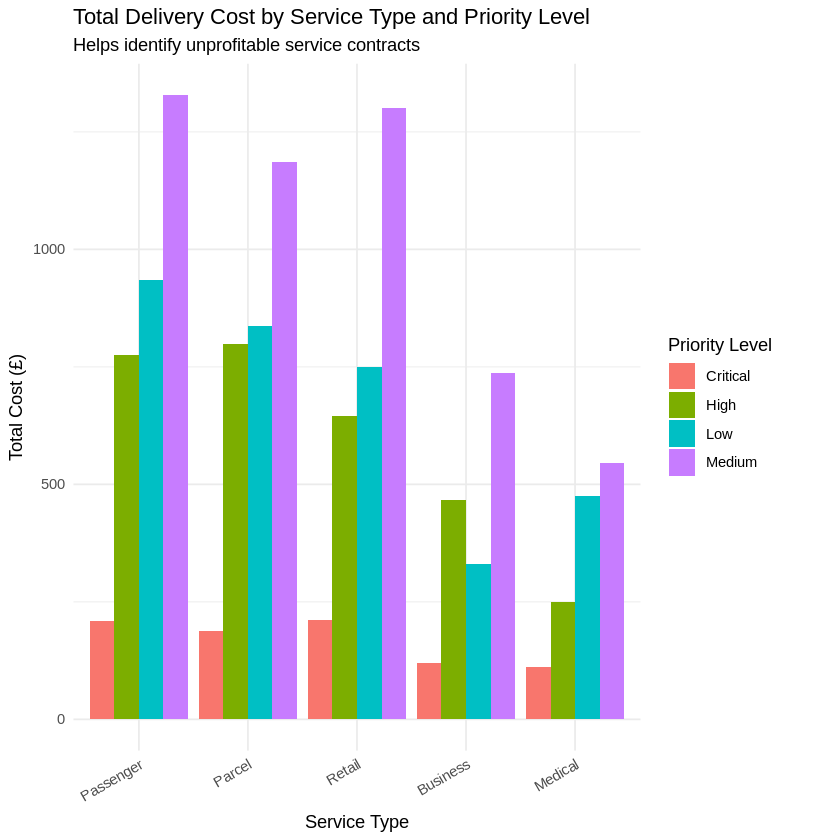

In [ ]:
ggplot(q7, aes(x = reorder(service_type, -total_cost),
               y = total_cost,
               fill = priority_level)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Total Delivery Cost by Service Type and Priority Level",
       subtitle = "Helps identify unprofitable service contracts",
       x = "Service Type", y = "Total Cost (£)",
       fill = "Priority Level") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

## Section 2: R Analytics
Statistical analysis, trend identification and visualisation using R
to uncover patterns in NorthStar's operational performance data.

In [ ]:
# Statistical overview of core operational metrics
# This gives us the distribution of delays, costs and ratings

cat("=== DELIVERY COST STATISTICS ===\n")
print(summary(deliveries$fuel_or_charge_cost))

cat("\n=== CUSTOMER RATING STATISTICS ===\n")
print(summary(deliveries$customer_rating_post_delivery))

cat("\n=== ROUTE DISTANCE STATISTICS ===\n")
print(summary(deliveries$route_distance_km))

cat("\n=== MANUAL OVERRIDE STATISTICS ===\n")
print(summary(deliveries$manual_route_override_count))

=== DELIVERY COST STATISTICS ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.500   9.925  12.645  12.841  15.697  29.430 

=== CUSTOMER RATING STATISTICS ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

=== ROUTE DISTANCE STATISTICS ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 

=== MANUAL OVERRIDE STATISTICS ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  1.0000  0.9695  2.0000  7.0000 


In [ ]:
# Check correlation between key numeric variables
# Are overrides, distance and cost related to poor ratings?

cor_data <- deliveries[, c("fuel_or_charge_cost",
                            "route_distance_km",
                            "manual_route_override_count",
                            "customer_rating_post_delivery")]

cor_data <- na.omit(cor_data)
cor_matrix <- cor(cor_data)

cat("=== CORRELATION MATRIX ===\n")
print(round(cor_matrix, 3))

=== CORRELATION MATRIX ===
                              fuel_or_charge_cost route_distance_km
fuel_or_charge_cost                         1.000             0.527
route_distance_km                           0.527             1.000
manual_route_override_count                 0.099             0.199
customer_rating_post_delivery              -0.059             0.029
                              manual_route_override_count
fuel_or_charge_cost                                 0.099
route_distance_km                                   0.199
manual_route_override_count                         1.000
customer_rating_post_delivery                      -0.060
                              customer_rating_post_delivery
fuel_or_charge_cost                                  -0.059
route_distance_km                                     0.029
manual_route_override_count                          -0.060
customer_rating_post_delivery                         1.000


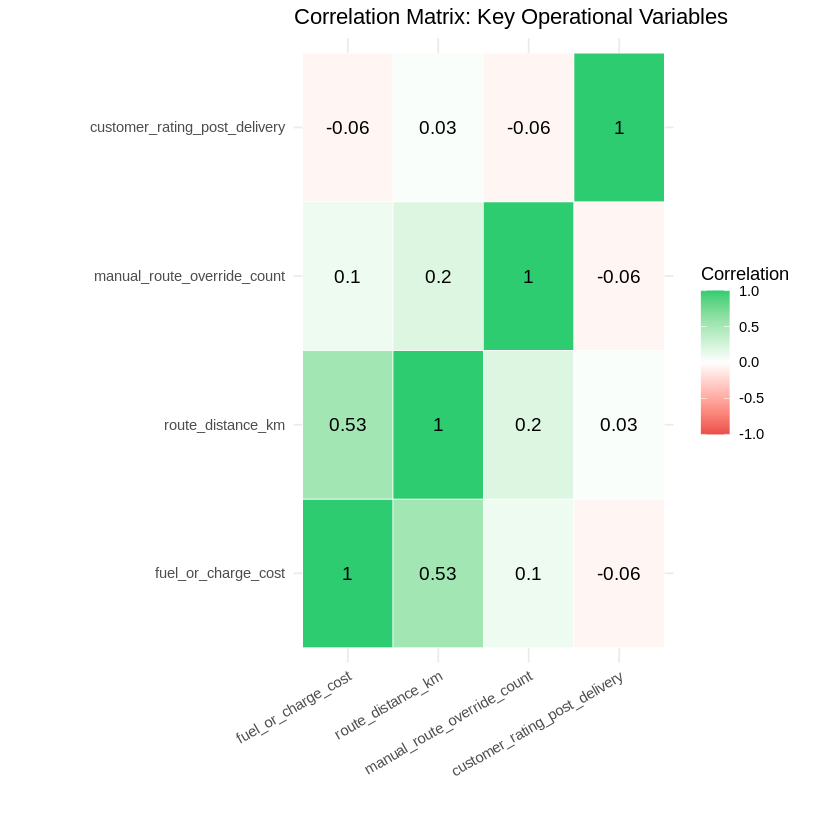

In [ ]:
# Heatmap of correlations between operational variables
cor_melted <- as.data.frame(as.table(cor_matrix))

ggplot(cor_melted, aes(x = Var1, y = Var2, fill = Freq)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(Freq, 2)), size = 4) +
  scale_fill_gradient2(low = "#eb4d4b", mid = "white", high = "#2ecc71",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Correlation Matrix: Key Operational Variables",
       x = "", y = "", fill = "Correlation") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

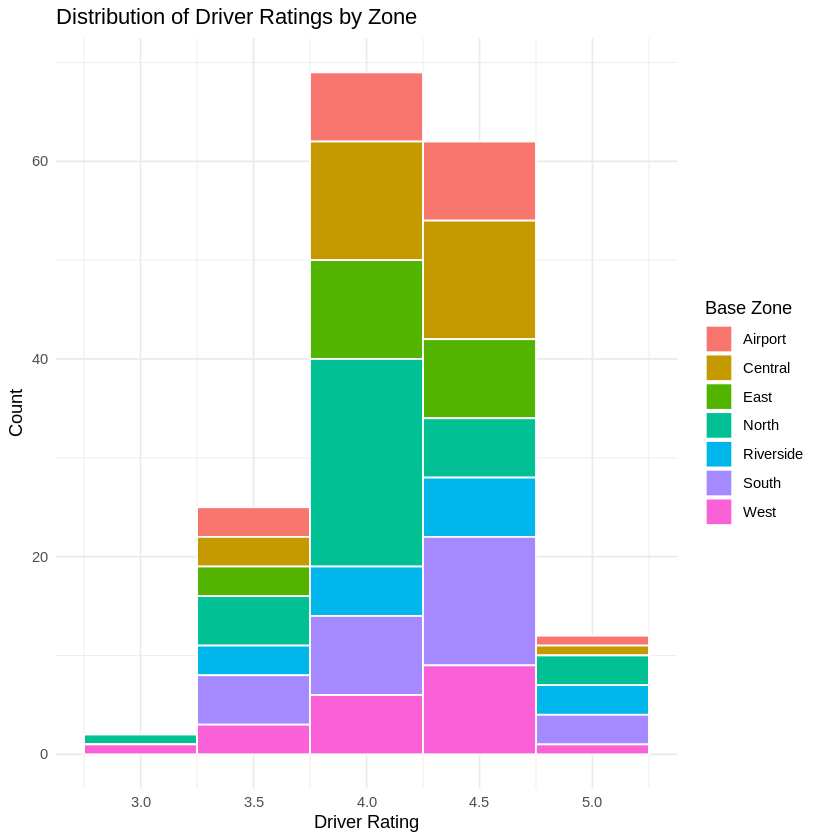

In [ ]:
# Distribution of driver ratings across the workforce
# Are low rated drivers concentrated in certain zones?

ggplot(drivers, aes(x = driver_rating, fill = base_zone)) +
  geom_histogram(binwidth = 0.5, colour = "white") +
  labs(title = "Distribution of Driver Ratings by Zone",
       x = "Driver Rating", y = "Count",
       fill = "Base Zone") +
  theme_minimal()

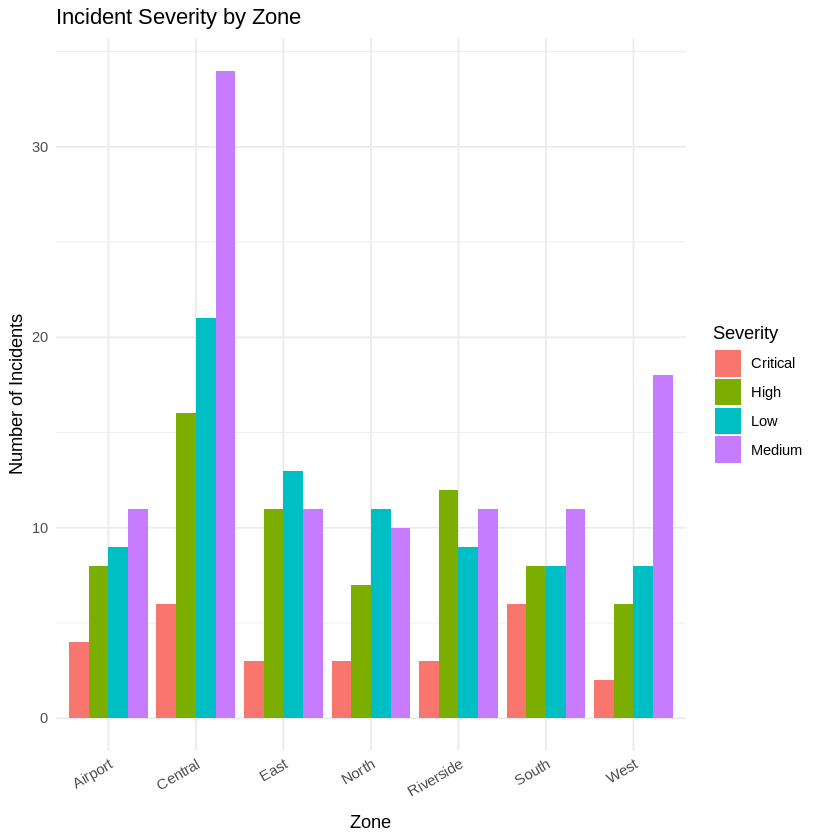

In [ ]:
# Which zones have the most serious incidents?
incident_zone <- merge(incidents, deliveries[, c("delivery_id","hub_id")],
                       by = "delivery_id", all.x = TRUE)
incident_zone <- merge(incident_zone, hubs[, c("hub_id","zone")],
                       by = "hub_id", all.x = TRUE)

ggplot(incident_zone, aes(x = zone, fill = severity)) +
  geom_bar(position = "dodge") +
  labs(title = "Incident Severity by Zone",
       x = "Zone", y = "Number of Incidents",
       fill = "Severity") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

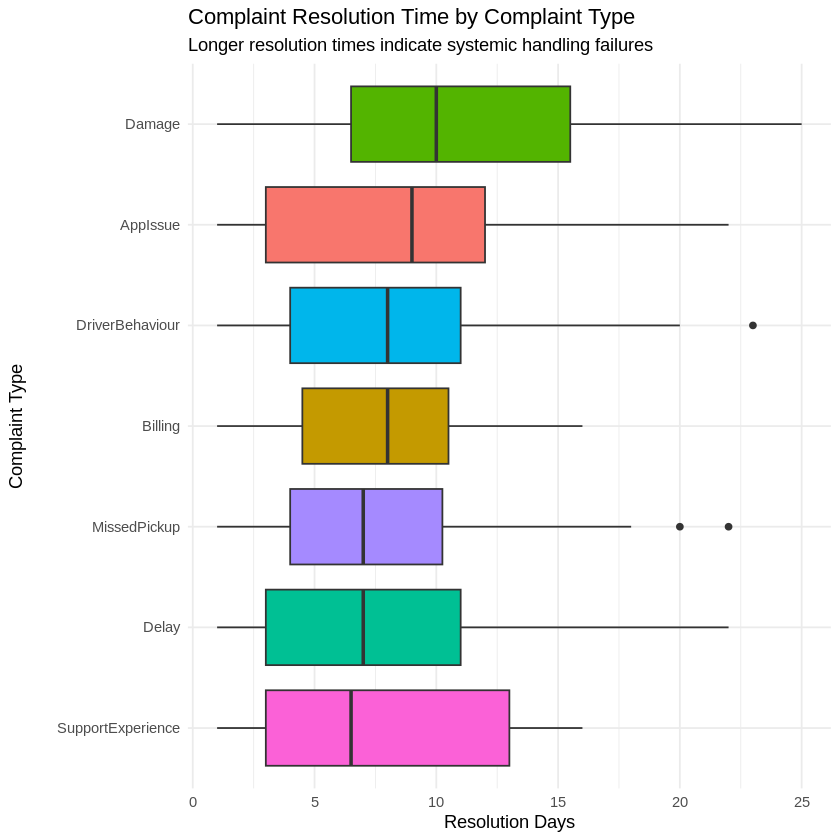

In [ ]:
# How long does it take to resolve different complaint types?
# Longer resolution = more customer dissatisfaction

ggplot(complaints, aes(x = reorder(complaint_type, resolution_days, median),
                        y = resolution_days,
                        fill = complaint_type)) +
  geom_boxplot() +
  coord_flip() +
  labs(title = "Complaint Resolution Time by Complaint Type",
       subtitle = "Longer resolution times indicate systemic handling failures",
       x = "Complaint Type", y = "Resolution Days") +
  theme_minimal() +
  theme(legend.position = "none")

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


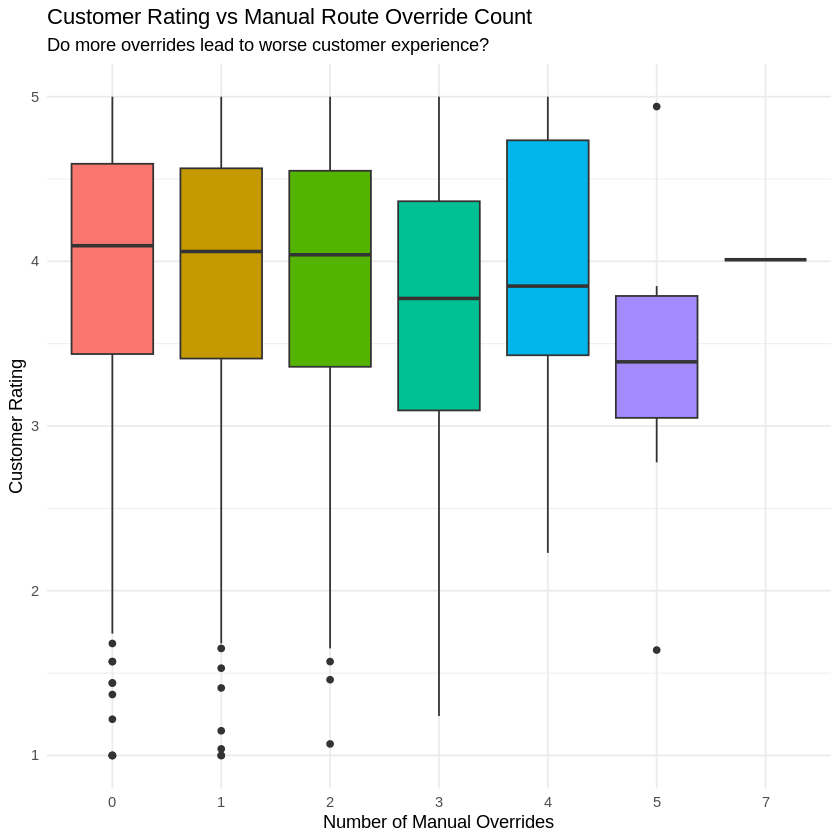

In [ ]:
# Does higher override count lead to lower customer satisfaction?

ggplot(deliveries, aes(x = factor(manual_route_override_count),
                        y = customer_rating_post_delivery,
                        fill = factor(manual_route_override_count))) +
  geom_boxplot() +
  labs(title = "Customer Rating vs Manual Route Override Count",
       subtitle = "Do more overrides lead to worse customer experience?",
       x = "Number of Manual Overrides", y = "Customer Rating") +
  theme_minimal() +
  theme(legend.position = "none")

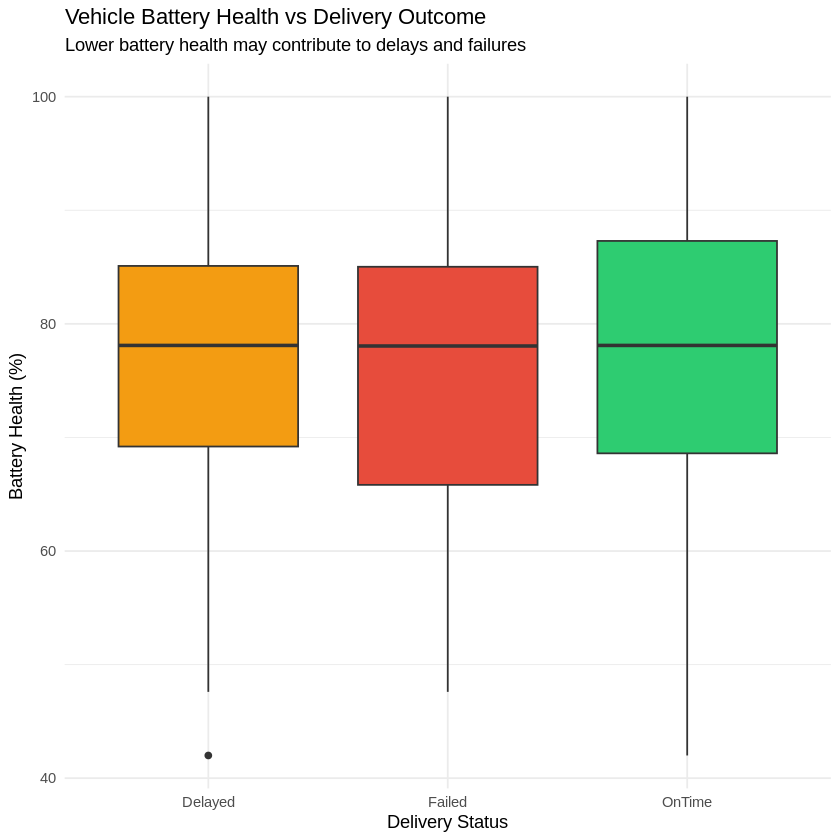

In [ ]:
# Are low battery vehicles causing more delivery failures?
# Management suspects maintenance issues detected too late

deliveries_vehicles <- merge(deliveries, vehicles[, c("vehicle_id", "battery_health_pct", "maintenance_status")],
                              by = "vehicle_id", all.x = TRUE)

deliveries_vehicles <- deliveries_vehicles[!is.na(deliveries_vehicles$battery_health_pct), ]

ggplot(deliveries_vehicles, aes(x = delivery_status,
                                 y = battery_health_pct,
                                 fill = delivery_status)) +
  geom_boxplot() +
  scale_fill_manual(values = c("OnTime"="#2ecc71", "Delayed"="#f39c12", "Failed"="#e74c3c")) +
  labs(title = "Vehicle Battery Health vs Delivery Outcome",
       subtitle = "Lower battery health may contribute to delays and failures",
       x = "Delivery Status", y = "Battery Health (%)") +
  theme_minimal() +
  theme(legend.position = "none")

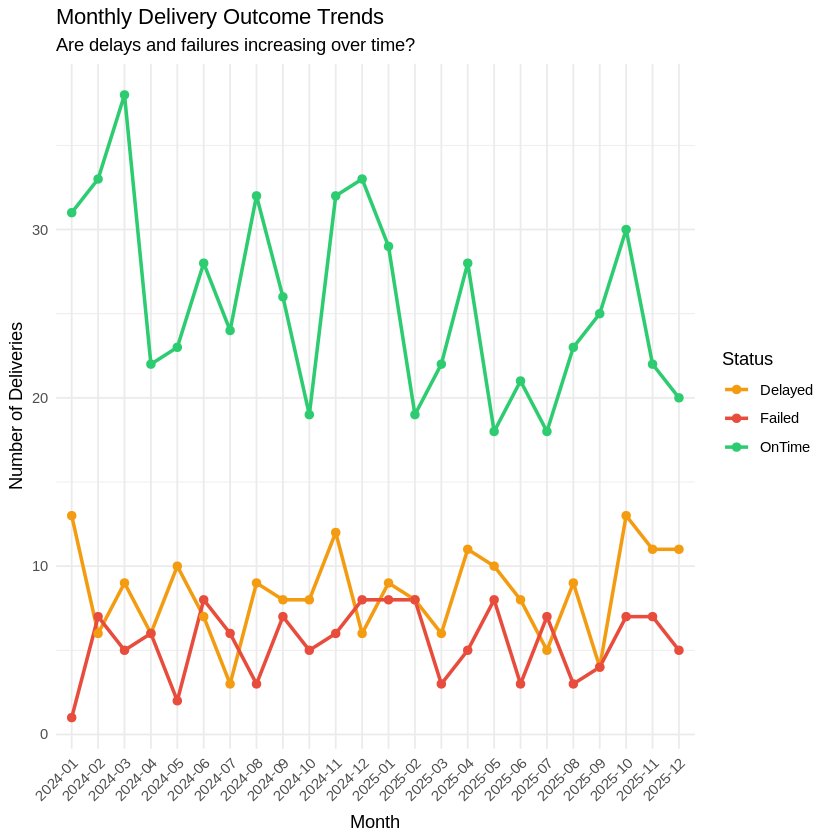

In [ ]:
# Are failures getting worse over time?
deliveries$dispatch_time <- as.Date(deliveries$dispatch_time)
deliveries$month <- format(deliveries$dispatch_time, "%Y-%m")

monthly_trend <- aggregate(delivery_id ~ month + delivery_status,
                            data = deliveries, FUN = length)
names(monthly_trend)[3] <- "count"

ggplot(monthly_trend, aes(x = month, y = count,
                           colour = delivery_status,
                           group = delivery_status)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_colour_manual(values = c("OnTime"="#2ecc71", "Delayed"="#f39c12", "Failed"="#e74c3c")) +
  labs(title = "Monthly Delivery Outcome Trends",
       subtitle = "Are delays and failures increasing over time?",
       x = "Month", y = "Number of Deliveries",
       colour = "Status") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

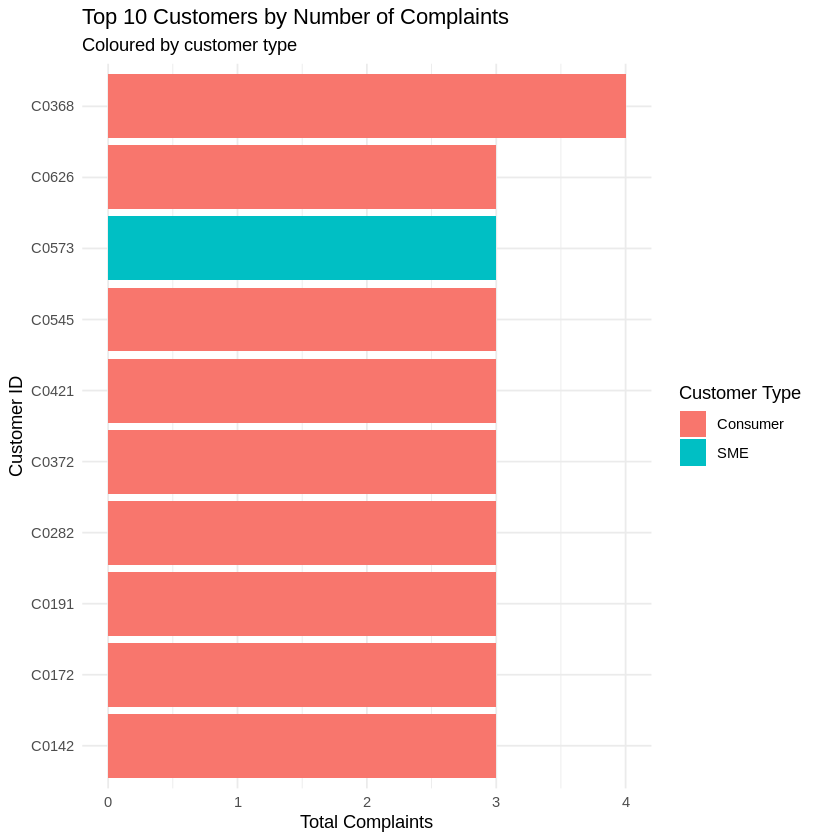

In [ ]:
# Which customers complain the most and are they high value?
# Links customer behaviour to service quality issues

cust_complaints <- merge(complaints, customers[, c("customer_id", "customer_type", "loyalty_score")],
                          by = "customer_id", all.x = TRUE)

top_complainers <- aggregate(complaint_id ~ customer_id + customer_type + loyalty_score,
                              data = cust_complaints, FUN = length)
names(top_complainers)[4] <- "total_complaints"
top_complainers <- top_complainers[order(-top_complainers$total_complaints), ][1:10, ]

ggplot(top_complainers, aes(x = reorder(customer_id, total_complaints),
                             y = total_complaints,
                             fill = customer_type)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Top 10 Customers by Number of Complaints",
       subtitle = "Coloured by customer type",
       x = "Customer ID", y = "Total Complaints",
       fill = "Customer Type") +
  theme_minimal()